# Handling Class Imbalance with SMOTE

This notebook addresses class imbalance in the stroke dataset using SMOTE (Synthetic Minority Over-sampling Technique). We balance the training data to improve model performance on the minority class (stroke cases).

## 1. Setup and Load Data

Import required libraries and load the cleaned training dataset prepared in the previous preprocessing steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

# Load dữ liệu sạch (đã xử lý missing & outlier) từ bước trước
# Chỉ load tập TRAIN để xử lý SMOTE
try:
    df_train = pd.read_csv('../data/processed/train_clean_final.csv')
    print("✅ Đã load file Train sạch.")
    print(f"   Kích thước ban đầu: {df_train.shape}")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy '../data/processed/train_clean_final.csv'. Hãy chạy bước xử lý Outlier trước.")

✅ Đã load file Train sạch.
   Kích thước ban đầu: (42063, 18)


## 2. Prepare Data for SMOTE

Separate features and target variable. Convert categorical features to numeric using one-hot encoding, as SMOTE requires numeric data to calculate distances.

In [2]:
# 2.1. Tách Feature (X) và Target (y)
# Loại bỏ cột 'id' (nếu có) vì nó không mang ý nghĩa dự đoán
cols_to_drop = ['stroke', 'id', 'source']
# Lọc chỉ những cột thực sự tồn tại trong df
cols_to_drop = [c for c in cols_to_drop if c in df_train.columns]

X_train = df_train.drop(columns=cols_to_drop)
y_train = df_train['stroke']

# 2.2. Mã hóa dữ liệu (One-Hot Encoding)
# SMOTE là thuật toán toán học, nó KHÔNG hiểu chữ (như 'Male', 'Urban').
# Ta cần chuyển hết các cột Object sang số (0/1).
print("\n--- Kiểm tra kiểu dữ liệu ---")
object_cols = X_train.select_dtypes(include=['object']).columns

if len(object_cols) > 0:
    print(f"⚠️ Phát hiện các cột dạng chữ: {list(object_cols)}")
    print("   -> Đang thực hiện One-Hot Encoding...")
    X_train_encoded = pd.get_dummies(X_train, columns=object_cols, drop_first=True)
else:
    print("✅ Tất cả dữ liệu đã là dạng số. Sẵn sàng cho SMOTE.")
    X_train_encoded = X_train.copy()


--- Kiểm tra kiểu dữ liệu ---
✅ Tất cả dữ liệu đã là dạng số. Sẵn sàng cho SMOTE.


## 3. Check Class Imbalance Before Treatment

Examine the distribution of the stroke target variable before applying SMOTE. This baseline helps us understand the severity of class imbalance.

In [3]:
counter_before = Counter(y_train)
print(f"Phân bố gốc: {counter_before}")
print(f"- Tỷ lệ Đột quỵ (1): {counter_before[1] / len(y_train) * 100:.2f}%")

Phân bố gốc: Counter({0: 40016, 1: 2047})
- Tỷ lệ Đột quỵ (1): 4.87%


## 4. Apply SMOTE (Synthetic Minority Over-sampling Technique)

Generate synthetic samples for the minority class (stroke cases) to balance the dataset. Use a sampling_strategy of 0.8 to avoid creating excessive synthetic data while improving balance.

In [4]:
print("\n⏳ Đang chạy SMOTE...")

# sampling_strategy=0.8 nghĩa là: Số lượng ca Đột quỵ sẽ được sinh ra
# sao cho bằng 80% số lượng ca Không đột quỵ.
# (Không nhất thiết phải 1.0, mức 0.8 giúp giảm thiểu việc sinh ra quá nhiều dữ liệu giả)
smote = SMOTE(sampling_strategy=0.8, random_state=42)

X_train_resample, y_train_resample = smote.fit_resample(X_train_encoded, y_train)

counter_after = Counter(y_train_resample)
print(f"Phân bố sau SMOTE: {counter_after}")
print(f"- Tỷ lệ Đột quỵ mới: {counter_after[1] / len(y_train_resample) * 100:.2f}%")


⏳ Đang chạy SMOTE...
Phân bố sau SMOTE: Counter({0: 40016, 1: 32012})
- Tỷ lệ Đột quỵ mới: 44.44%
Phân bố sau SMOTE: Counter({0: 40016, 1: 32012})
- Tỷ lệ Đột quỵ mới: 44.44%


## 5. Visualize Results

Create side-by-side comparison of class distribution before and after SMOTE treatment. This visualization clearly shows how SMOTE improves the balance between stroke and non-stroke cases.

C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\4025751843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='Blues')
C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\4025751843.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resample, ax=axes[1], palette='Oranges')


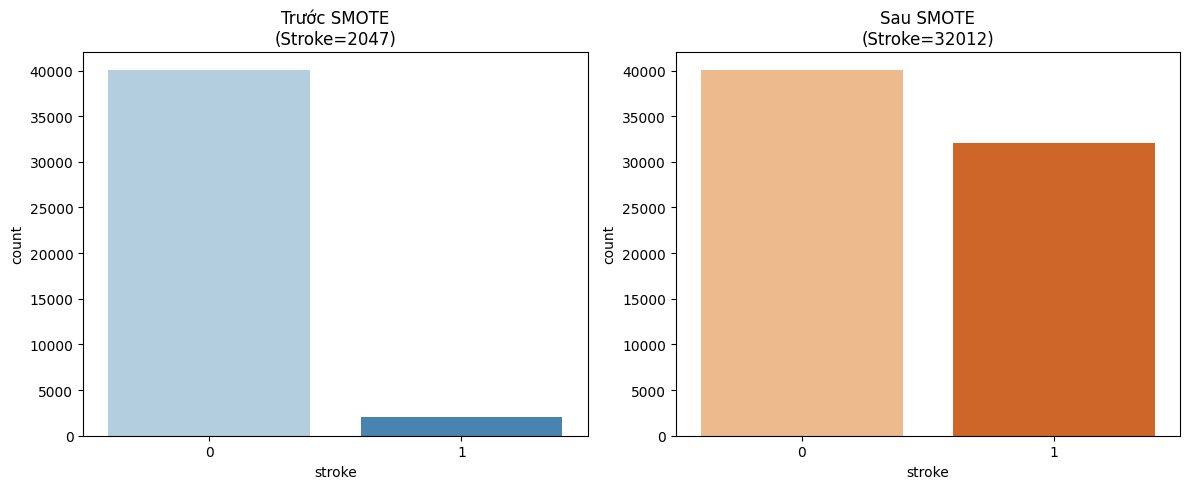

In [5]:
# Vẽ biểu đồ so sánh trước và sau
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trước SMOTE
sns.countplot(x=y_train, ax=axes[0], palette='Blues')
axes[0].set_title(f"Trước SMOTE\n(Stroke={counter_before[1]})")

# Sau SMOTE
sns.countplot(x=y_train_resample, ax=axes[1], palette='Oranges')
axes[1].set_title(f"Sau SMOTE\n(Stroke={counter_after[1]})")

plt.tight_layout()
plt.show()

## 6. Save Final Balanced Data

Combine the resampled features and target variable, then save as CSV for use in the modeling phase. The test set will be processed separately to maintain proper data separation.

In [6]:
# Ghép X và y lại thành 1 dataframe hoàn chỉnh
df_train_final = X_train_resample.copy()
df_train_final['stroke'] = y_train_resample

# Lưu file
save_path = '../data/processed/train_final_balanced.csv'
df_train_final.to_csv(save_path, index=False)

print("\n" + "="*50)
print(f"✅ HOÀN TẤT! File dữ liệu cuối cùng cho model: {save_path}")
print(f"Tổng số dòng dữ liệu training: {len(df_train_final)}")
print("="*50)


✅ HOÀN TẤT! File dữ liệu cuối cùng cho model: ../data/processed/train_final_balanced.csv
Tổng số dòng dữ liệu training: 72028


## Next Steps

The balanced training data is now ready for modeling. To proceed with building predictive models:

👉 **Create a modeling notebook** that:
- Loads `train_final_balanced.csv` for model training
- Loads `test_clean_final.csv` for evaluation
- Applies the same one-hot encoding to the test set to ensure consistency
- Trains various classification models
- Evaluates performance on balanced test data

⚠️ **Important**: The test set should NOT be resampled. It remains imbalanced to provide realistic performance metrics.